In [77]:
"""
CBIS-DDSM v3 — RadImageNet 預訓練版本
======================================
權重來源: https://huggingface.co/Lab-Rasool/RadImageNet
- ResNet50.pt (PyTorch 格式，免轉換)
- 此 repo 使用 ImageNet normalization (跟 v1/v2 一樣)
- 論文: Radiology: AI 2022, MIT License

重點變動 vs v2:
1. 預訓練權重從 ImageNet (torchvision) → RadImageNet
2. 架構改回 ResNet50 (匹配 RadImageNet 權重)
3. 自動從 HuggingFace 下載權重 (透過 huggingface_hub)
4. 支援完整 model 和 state_dict 兩種權重格式
"""

'\nCBIS-DDSM v3 — RadImageNet 預訓練版本\n======================================\n權重來源: https://huggingface.co/Lab-Rasool/RadImageNet\n- ResNet50.pt (PyTorch 格式，免轉換)\n- 此 repo 使用 ImageNet normalization (跟 v1/v2 一樣)\n- 論文: Radiology: AI 2022, MIT License\n\n重點變動 vs v2:\n1. 預訓練權重從 ImageNet (torchvision) → RadImageNet\n2. 架構改回 ResNet50 (匹配 RadImageNet 權重)\n3. 自動從 HuggingFace 下載權重 (透過 huggingface_hub)\n4. 支援完整 model 和 state_dict 兩種權重格式\n'

In [78]:
import os
import sys
import random
from pathlib import Path
from collections import Counter, OrderedDict

In [79]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

============================================================
1. 環境偵測
============================================================

In [80]:
IN_COLAB = "google.colab" in sys.modules

In [81]:
if IN_COLAB:
    DATA_ROOT = Path("/content/data/CBIS_DDSM_Kaggle")
    WORK_DIR = Path("/content")
    if not DATA_ROOT.exists():
        from google.colab import files
        kaggle_dir = Path.home() / ".kaggle"
        kaggle_dir.mkdir(exist_ok=True)
        if not (kaggle_dir / "kaggle.json").exists():
            print("請上傳 kaggle.json：")
            files.upload()
            Path("kaggle.json").rename(kaggle_dir / "kaggle.json")
            os.chmod(kaggle_dir / "kaggle.json", 0o600)
        os.system("pip install -q kaggle")
        os.system("kaggle datasets download -d dynemiesizumaki/cbis-ddsmpng "
                  "-p /content/data --unzip")
else:
    DATA_ROOT = Path(r"C:\Users\s9988\Documents\datasets\cbis-ddsm\CBIS_DDSM_Kaggle")
    WORK_DIR = Path(r"C:\Users\s9988\Documents")

In [82]:
RADIMAGENET_CKPT = WORK_DIR / "ResNet50.pt"

In [83]:
if not RADIMAGENET_CKPT.exists():
    print("從 HuggingFace 下載 RadImageNet ResNet50 權重...")
    try:
        from huggingface_hub import hf_hub_download
    except ImportError:
        os.system("pip install -q huggingface_hub")
        from huggingface_hub import hf_hub_download
    downloaded = hf_hub_download(
        repo_id="Lab-Rasool/RadImageNet",
        filename="ResNet50.pt",
        local_dir=str(WORK_DIR),
    )
    print(f"下載完成: {downloaded}")

In [84]:
assert RADIMAGENET_CKPT.exists(), f"找不到 RadImageNet 權重: {RADIMAGENET_CKPT}"
print(f"權重檔: {RADIMAGENET_CKPT} ({RADIMAGENET_CKPT.stat().st_size / 1e6:.1f} MB)")

權重檔: /content/ResNet50.pt (94.3 MB)


============================================================
2. 設定
============================================================

In [85]:
CONFIG = {
    "img_size":     224,
    "batch_size":   32,
    "num_epochs":   30,
    "patience":     8,
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "val_split":    0.15,
    "test_split":   0.15,
    "num_workers":  2 if IN_COLAB else 0,
    "seed":         42,
    "bbox_margin":  0.30,
    # Lab-Rasool/RadImageNet 用 ImageNet 標準化 (見其 README)
    # 如果效果不好可切回 "radimagenet" (即 [-1,1] 範圍)
    "norm_mode":    "radimagenet",     # "imagenet" 或 "radimagenet"
}

In [86]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


============================================================
3. 載入 RadImageNet 權重 (容錯式)
============================================================

In [88]:
def load_radimagenet_weights(ckpt_path: Path) -> nn.Module:
    """
    支援多種權重格式：
    - 完整 nn.Module 物件 (Lab-Rasool 用這種)
    - 直接 state_dict
    - 包在 'state_dict' / 'model' / 'model_state_dict' 裡
    - 帶 'module.' 前綴 (DataParallel)
    - layer name 跟 torchvision 不一致 (timm vs torchvision)
    """
    raw = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    # Step A: 找到真正的 state_dict
    if isinstance(raw, nn.Module):
        print("  載入的是完整 model 物件，提取 state_dict")
        state_dict = raw.state_dict()
    elif isinstance(raw, dict):
        for key in ["state_dict", "model_state_dict", "model", "net"]:
            if key in raw and isinstance(raw[key], dict):
                state_dict = raw[key]
                print(f"  從 '{key}' 取得 state_dict")
                break
        else:
            state_dict = raw
            print("  直接使用 dict 作為 state_dict")
    else:
        state_dict = raw

    # Step B: 移除 'module.' 前綴 (DataParallel 殘留)
    new_state = OrderedDict()
    for k, v in state_dict.items():
        new_k = k
        if new_k.startswith("module."):
            new_k = new_k[len("module."):]
        # timm 命名可能是 'backbone.' 開頭
        if new_k.startswith("backbone."):
            new_k = new_k[len("backbone."):]
        new_state[new_k] = v

    # Step B2: 偵測 Sequential 數字 key (Lab-Rasool RadImageNet 用這種)
    #          ‘0’->conv1, ‘1’->bn1, ‘4’->layer1, …
    first_key = next(iter(new_state.keys()), "")
    if first_key.split(".")[0].isdigit():
        print("  偵測到 Sequential 數字 key，自動重命名為 torchvision 標準名稱")
        seq_to_resnet = {
            "0": "conv1", "1": "bn1",
            "4": "layer1", "5": "layer2", "6": "layer3", "7": "layer4",
            "9": "fc",
        }
        remapped = OrderedDict()
        n_remap = 0
        for k, v in new_state.items():
            parts = k.split(".")
            if parts[0] in seq_to_resnet:
                parts[0] = seq_to_resnet[parts[0]]
                remapped[".".join(parts)] = v
                n_remap += 1
            elif parts[0] in ("2", "3", "8"):
                # 2=relu, 3=maxpool, 8=avgpool — 無參數，跳過
                pass
            else:
                remapped[k] = v
        new_state = remapped
        print(f"  重命名了 {n_remap} 個 key")

    # Step C: 建立 ResNet50 (隨機初始化)，載入權重
    model = models.resnet50(weights=None)
    missing, unexpected = model.load_state_dict(new_state, strict=False)

    print(f"\n載入結果:")
    print(f"  - 模型總參數量: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  - 載入到的權重: {sum(v.numel() for v in new_state.values()):,}")
    print(f"  - Missing keys ({len(missing)}): {missing[:5]}{'...' if len(missing) > 5 else ''}")
    print(f"  - Unexpected keys ({len(unexpected)}): {unexpected[:5]}{'...' if len(unexpected) > 5 else ''}")

    # 健康度警告
    if len(missing) > 10:
        print("\n  ⚠️  警告: missing keys 太多，權重可能沒對上！")
        print("      模型可能只載入了一部分，效果會接近從零訓練")
    if len(unexpected) > 10:
        print("\n  ⚠️  警告: unexpected keys 太多，可能是不同架構的權重")

    # Step D: Sanity check — 第一個 conv 的權重不應該是接近 0 的隨機值
    first_conv_weight = model.conv1.weight
    weight_std = first_conv_weight.std().item()
    weight_abs_mean = first_conv_weight.abs().mean().item()
    print(f"\n  Sanity check - conv1 weight std={weight_std:.4f}, abs_mean={weight_abs_mean:.4f}")
    if weight_std < 0.01 or weight_abs_mean < 0.01:
        print("  ⚠️  conv1 權重接近 0，可能根本沒載入到預訓練權重！")
    else:
        print("  ✓ conv1 權重看起來像是有訓練過的 (非隨機初始化)")

    return model

In [89]:
print("\n=== 載入 RadImageNet 權重 ===")
backbone = load_radimagenet_weights(RADIMAGENET_CKPT)


=== 載入 RadImageNet 權重 ===
  直接使用 dict 作為 state_dict
  偵測到 Sequential 數字 key，自動重命名為 torchvision 標準名稱
  重命名了 318 個 key

載入結果:
  - 模型總參數量: 25,557,032
  - 載入到的權重: 23,561,205
  - Missing keys (2): ['fc.weight', 'fc.bias']
  - Unexpected keys (0): []

  Sanity check - conv1 weight std=0.3153, abs_mean=0.2480
  ✓ conv1 權重看起來像是有訓練過的 (非隨機初始化)


============================================================
4. 包裝成分類模型 (凍結大部分、解凍 layer4 + 換 fc)
============================================================

In [90]:
def wrap_for_classification(backbone: nn.Module, num_classes=2) -> nn.Module:
    for p in backbone.parameters():
        p.requires_grad = True

    backbone.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(backbone.fc.in_features, num_classes),
    )
    return backbone

In [91]:
model = wrap_for_classification(backbone, 2).to(device)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n可訓練參數: {n_train:,}")


可訓練參數: 23,512,130


============================================================
5. 資料 (沿用 v2 的 bbox-crop)
============================================================

In [92]:
def scan_dataset(root: Path) -> pd.DataFrame:
    rows = []
    for class_name, label in {"BENIGN": 0, "MALIGNANT": 1}.items():
        for case_dir in (root / class_name).iterdir():
            if not case_dir.is_dir():
                continue
            full_img = case_dir / "full_image.png"
            mask = case_dir / "roi_mask.png"
            if not (full_img.exists() and mask.exists()):
                continue
            parts = case_dir.name.split("_")
            rows.append({
                "full_image_path": str(full_img),
                "mask_path":       str(mask),
                "label":           label,
                "patient_id":      f"{parts[0]}_{parts[1]}",
                "case_id":         case_dir.name,
                "class":           class_name,
            })
    return pd.DataFrame(rows)

In [93]:
df = scan_dataset(DATA_ROOT)
print(f"\n總影像數: {len(df)}, 病人數: {df['patient_id'].nunique()}")
print(df["class"].value_counts())


總影像數: 458, 病人數: 398
class
BENIGN       269
MALIGNANT    189
Name: count, dtype: int64


In [94]:
def patient_split(df, val_size, test_size, seed):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tv_idx, te_idx = next(gss1.split(df, groups=df["patient_id"]))
    df_tv = df.iloc[tv_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)
    val_ratio = val_size / (1.0 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    tr_idx, val_idx = next(gss2.split(df_tv, groups=df_tv["patient_id"]))
    return (df_tv.iloc[tr_idx].reset_index(drop=True),
            df_tv.iloc[val_idx].reset_index(drop=True), df_te)

In [95]:
df_train, df_val, df_test = patient_split(df, CONFIG["val_split"], CONFIG["test_split"], CONFIG["seed"])
print(f"Train/Val/Test: {len(df_train)}/{len(df_val)}/{len(df_test)}")

Train/Val/Test: 310/77/71


In [96]:
def get_lesion_bbox(mask_path, margin_ratio):
    mask = np.array(Image.open(mask_path).convert("L"))
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    H, W = mask.shape
    y0, y1 = int(ys.min()), int(ys.max())
    x0, x1 = int(xs.min()), int(xs.max())
    bh, bw = y1 - y0, x1 - x0
    my, mx = int(bh * margin_ratio), int(bw * margin_ratio)
    return (max(0, x0 - mx), max(0, y0 - my),
            min(W, x1 + mx), min(H, y1 + my))

In [97]:
class BboxCropDataset(Dataset):
    def __init__(self, df, transform, margin):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.margin = margin

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_image_path"]).convert("RGB")
        bbox = get_lesion_bbox(row["mask_path"], self.margin)
        if bbox:
            img = img.crop(bbox)
        return self.transform(img), int(row["label"])

============================================================
6. Normalization — 重要！
============================================================
RadImageNet 官方預處理是 image/255*2-1 = [-1,1] 範圍
等效於 mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]
但有些 HuggingFace 轉檔版本可能改成 ImageNet stats
如果第一個 epoch 的 val_acc 接近 0.5 (隨機)，切換 norm_mode 重試

In [98]:
if CONFIG["norm_mode"] == "radimagenet":
    NORM_MEAN = [0.5, 0.5, 0.5]
    NORM_STD = [0.5, 0.5, 0.5]
    print("\n使用 RadImageNet 標準化: [-1, 1] 範圍")
else:
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]
    print("\n使用 ImageNet 標準化")


使用 RadImageNet 標準化: [-1, 1] 範圍


In [99]:
train_tfm = T.Compose([
    T.Resize((CONFIG["img_size"] + 32, CONFIG["img_size"] + 32)),
    T.RandomCrop(CONFIG["img_size"]),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])
eval_tfm = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])

In [100]:
train_ds = BboxCropDataset(df_train, train_tfm, CONFIG["bbox_margin"])
val_ds = BboxCropDataset(df_val, eval_tfm, CONFIG["bbox_margin"])
test_ds = BboxCropDataset(df_test, eval_tfm, CONFIG["bbox_margin"])

In [101]:
mk_loader = lambda ds, shuf: DataLoader(
    ds, batch_size=CONFIG["batch_size"], shuffle=shuf,
    num_workers=CONFIG["num_workers"], pin_memory=True,
)
train_loader = mk_loader(train_ds, True)
val_loader = mk_loader(val_ds, False)
test_loader = mk_loader(test_ds, False)

============================================================
7. Loss + Optimizer
============================================================

In [102]:
cnt = Counter(df_train["label"].tolist())
total = sum(cnt.values())
class_weights = torch.tensor(
    [total / (2 * cnt[i]) for i in [0, 1]], dtype=torch.float
).to(device)

In [103]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"]
)

============================================================
8. 健康度檢查 — 跑 1 epoch 看 val_auc 有沒有像話
============================================================

In [104]:
def evaluate(model, loader):
    model.eval()
    labels, probs, preds = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            probs.extend(torch.softmax(logits, 1)[:, 1].cpu().tolist())
            labels.extend(y.cpu().tolist())
            preds.extend(logits.argmax(1).cpu().tolist())
    return {
        "loss": total_loss / len(loader.dataset),
        "acc": float(np.mean(np.array(labels) == np.array(preds))),
        "auc": roc_auc_score(labels, probs) if len(set(labels)) > 1 else float("nan"),
        "labels": labels, "probs": probs, "preds": preds,
    }

In [105]:
print("\n=== 開始訓練 ===")
print("注意：第 1 epoch 結束後 val_auc 應該 > 0.55")
print("       如果接近 0.5，代表 normalization 或權重沒對上，請切換 norm_mode 重試\n")


=== 開始訓練 ===
注意：第 1 epoch 結束後 val_auc 應該 > 0.55
       如果接近 0.5，代表 normalization 或權重沒對上，請切換 norm_mode 重試



In [106]:
best_auc = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}
CKPT = "best_model_v3.pt"

In [107]:
for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    tr_loss = running / len(train_ds)
    vm = evaluate(model, val_loader)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vm["loss"])
    history["val_acc"].append(vm["acc"])
    history["val_auc"].append(vm["auc"])

    flag = ""
    if vm["auc"] > best_auc:
        best_auc = vm["auc"]
        torch.save(model.state_dict(), CKPT)
        patience_counter = 0
        flag = " ← saved"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']:02d} | "
          f"train_loss={tr_loss:.4f} | val_loss={vm['loss']:.4f} | "
          f"val_acc={vm['acc']:.4f} | val_auc={vm['auc']:.4f}{flag}")

    if epoch == 1 and vm["auc"] < 0.55:
        print("\n  ⚠️  Epoch 1 val_auc < 0.55，預訓練權重可能沒對上！")
        print("      建議：把 CONFIG['norm_mode'] 從 'radimagenet' 改為 'imagenet' 重跑")
        print("      或檢查權重檔來源是否正確\n")

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}")
        break

Epoch 01/30 | train_loss=0.7115 | val_loss=0.6917 | val_acc=0.5325 | val_auc=0.5526 ← saved
Epoch 02/30 | train_loss=0.6819 | val_loss=0.6887 | val_acc=0.5455 | val_auc=0.5680 ← saved
Epoch 03/30 | train_loss=0.6739 | val_loss=0.6986 | val_acc=0.5325 | val_auc=0.5596
Epoch 04/30 | train_loss=0.6734 | val_loss=0.6847 | val_acc=0.5455 | val_auc=0.5701 ← saved
Epoch 05/30 | train_loss=0.6562 | val_loss=0.6824 | val_acc=0.5455 | val_auc=0.5926 ← saved
Epoch 06/30 | train_loss=0.6735 | val_loss=0.6792 | val_acc=0.5584 | val_auc=0.5919
Epoch 07/30 | train_loss=0.6424 | val_loss=0.6816 | val_acc=0.5455 | val_auc=0.5891
Epoch 08/30 | train_loss=0.6535 | val_loss=0.6876 | val_acc=0.5844 | val_auc=0.6045 ← saved
Epoch 09/30 | train_loss=0.6347 | val_loss=0.6870 | val_acc=0.5714 | val_auc=0.6101 ← saved
Epoch 10/30 | train_loss=0.6442 | val_loss=0.6792 | val_acc=0.6104 | val_auc=0.6185 ← saved
Epoch 11/30 | train_loss=0.6043 | val_loss=0.6733 | val_acc=0.5714 | val_auc=0.6220 ← saved
Epoch 12/30 

In [108]:
print(f"\n最佳 Val AUC: {best_auc:.4f}")


最佳 Val AUC: 0.6396


============================================================
9. Test Set 評估
============================================================

In [109]:
model.load_state_dict(torch.load(CKPT, map_location=device))
tm = evaluate(model, test_loader)
print(f"\n=== Test Set ===")
print(f"AUC={tm['auc']:.4f}  Accuracy={tm['acc']:.4f}")
print(classification_report(tm["labels"], tm["preds"],
                            target_names=["BENIGN", "MALIGNANT"]))
cm = confusion_matrix(tm["labels"], tm["preds"])
print("Confusion Matrix:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"Sensitivity: {tp/(tp+fn):.4f}  Specificity: {tn/(tn+fp):.4f}  FN: {fn}")


=== Test Set ===
AUC=0.6667  Accuracy=0.6338
              precision    recall  f1-score   support

      BENIGN       0.74      0.60      0.66        42
   MALIGNANT       0.54      0.69      0.61        29

    accuracy                           0.63        71
   macro avg       0.64      0.64      0.63        71
weighted avg       0.66      0.63      0.64        71

Confusion Matrix:
[[25 17]
 [ 9 20]]
Sensitivity: 0.6897  Specificity: 0.5952  FN: 9


============================================================
10. 視覺化
============================================================

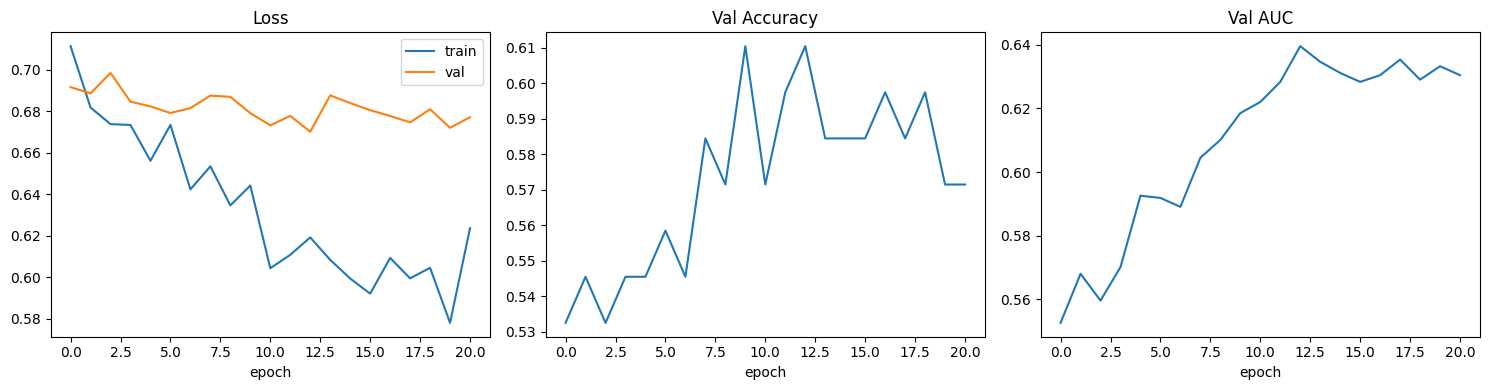

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_acc"])
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("epoch")
axes[2].plot(history["val_auc"])
axes[2].set_title("Val AUC"); axes[2].set_xlabel("epoch")
plt.tight_layout()
plt.savefig("training_curves_v3.png", dpi=120)
plt.show()